In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install nbformat

In [5]:
from nbformat import read, write

with open("/content/drive/MyDrive/NIET saqib/Tomato_Condition_Detection.ipynb", "r") as f:
    nb = read(f, as_version=4)

nb.metadata.pop('widgets', None)

with open("clean_notebook.ipynb", "w") as f:
    write(nb, f)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Define the path you provided
DATA_PATH = '/content/drive/MyDrive/data_analytics/DA_PROJECT'
# DATA_PATH = 'dataset/' (add your dataset path here after uploading dataset on drive )
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Categories identified: {class_names}")

Found 5551 files belonging to 3 classes.
Using 4441 files for training.
Found 5551 files belonging to 3 classes.
Using 1110 files for validation.
Categories identified: ['Old', 'Ripe', 'Unripe']


In [ ]:
# 1. Data Augmentation to prevent the model from memorizing specific images
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# 2. Base Model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 3. Final Architecture
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalize pixel values
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 739s 5s/step - accuracy: 0.8424 - loss: 0.3695 - val_accuracy: 0.9477 - val_loss: 0.1423
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.9608 - loss: 0.1020 - val_accuracy: 0.9595 - val_loss: 0.1066
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.9611 - loss: 0.0969 - val_accuracy: 0.9685 - val_loss: 0.0813
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.9733 - loss: 0.0741 - val_accuracy: 0.9640 - val_loss: 0.0938
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9753 - loss: 0.0663 - val_accuracy: 0.9685 - val_loss: 0.0807
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9729 - loss: 0.0666 - val_accuracy: 0.9676 - val_loss: 0.0813
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.9760 - loss: 0.0577 - val_accuracy: 0.9685 - val_loss: 0.0890
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.9801 - loss: 0.0

In [ ]:
# Save the model to your Drive folder
model_save_path = '/content/drive/MyDrive/data_analytics/tomato_classifier_final.h5'
model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/MyDrive/data_analytics/tomato_classifier_final.h5


In [ ]:
# Run this in a new session to load the model without re-training
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/data_analytics/tomato_classifier_final.h5')

# Now you can use loaded_model.predict() just like before!
print("Model loaded and ready for use.")

Model loaded and ready for use.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the architecture EXACTLY as you did before
IMG_SIZE = (224, 224)
class_names = ['old', 'ripe', 'unripe'] # Ensure these match your folders

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Re-create the structure
loaded_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

# 2. Load ONLY the weights from your saved file
# This bypasses the 'Value Error' related to layer configurations
loaded_model.load_weights('/content/drive/MyDrive/data_analytics/tomato_classifier_final.h5')

print("Model structure rebuilt and weights loaded successfully!")

Model structure rebuilt and weights loaded successfully!



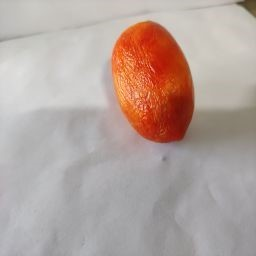

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import base64

# --- HELPER FUNCTIONS ---
def get_b64_image(path):
    with open(path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def run_prediction(btn):
    clear_output(wait=True)
    display(menu_title)
    display(button_box)

    print("Please select your tomato image...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 1. Process
        img = image.load_img(fn, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # 2. Predict
        predictions = loaded_model.predict(img_array, verbose=0)
        score = predictions[0]
        idx = np.argmax(score)
        label = class_names[idx].upper()
        conf = 100 * np.max(score)

        # 3. Theme
        colors = {"RIPE": "#2ecc71", "UNRIPE": "#f1c40f", "OLD": "#e74c3c"}
        theme = colors.get(label, "#3498db")

        # 4. Display Styled Result
        clear_output(wait=True)
        display(menu_title)
        display(button_box)

        display(HTML(f"""
        <div style="font-family: 'Segoe UI', sans-serif; border-radius: 15px; padding: 20px;
                    width: 450px; background-color: #ffffff; border: 1px solid #ddd; box-shadow: 0 4px 12px rgba(0,0,0,0.1); margin-top: 20px;">
            <div style="display: flex; align-items: center;">
                <img src="data:image/png;base64,{get_b64_image(fn)}" style="width: 120px; height: 120px; object-fit: cover; border-radius: 10px; border: 3px solid {theme};">
                <div style="margin-left: 20px;">
                    <p style="margin: 0; font-size: 12px; color: #888; text-transform: uppercase; letter-spacing: 1px;">Result</p>
                    <h2 style="margin: 0; color: {theme};">{label}</h2>
                    <p style="margin: 5px 0 0 0; font-size: 12px; color: #888;">Confidence: {conf:.1f}%</p>
                    <div style="background-color: #eee; border-radius: 5px; width: 150px; height: 10px; margin-top: 5px;">
                        <div style="background-color: {theme}; width: {conf}%; height: 10px; border-radius: 5px;"></div>
                    </div>
                </div>
            </div>
        </div>
        """))
        os.remove(fn)

def terminate(btn):
    clear_output()
    display(HTML("<h2 style='color: #e74c3c; font-family: sans-serif;'>Program Terminated.</h2>"))
    display(HTML("<p>You can re-run the cell to start again.</p>"))

# --- UI SETUP ---
menu_title = HTML("<h1 style='font-family: sans-serif; color: #444;'>🍅 Tomato Classifier</h1>")

# Create Buttons
btn_upload = widgets.Button(description="Check Another Image", button_style='success', icon='search')
btn_exit = widgets.Button(description="Exit Program", button_style='danger', icon='times')

# Link Functions to Buttons
btn_upload.on_click(run_prediction)
btn_exit.on_click(terminate)

# Layout
button_box = widgets.HBox([btn_upload, btn_exit])

# Start the App
display(menu_title)
display(button_box)
print("Click 'Check Another Image' to begin.")

In [ ]:
import pandas as pd

def build_model(base_layer, name):
    base_layer.trainable = False
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(1./255),
        base_layer,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(class_names), activation='softmax')
    ], name=name)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define the 3 algorithms
models_to_test = {
    "MobileNetV2": tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False),
    "ResNet50": tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False),
    "InceptionV3": tf.keras.applications.InceptionV3(input_shape=(224, 224, 3), include_top=False)
}

results = []

# Loop through and train each
for name, base in models_to_test.items():
    print(f"\n🚀 Training Algorithm: {name}...")
    m = build_model(base, name)
    history = m.fit(train_ds, validation_data=val_ds, epochs=5, verbose=0) # Shorter epochs for comparison

    val_acc = max(history.history['val_accuracy'])
    results.append({"Algorithm": name, "Best Accuracy": val_acc})
    print(f"✅ {name} reached {val_acc:.2%} accuracy.")

# Create a summary table
df_results = pd.DataFrame(results)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Training Algorithm: MobileNetV2...
✅ MobileNetV2 reached 98.38% accuracy.

🚀 Training Algorithm: ResNet50...
✅ ResNet50 reached 57.21% accuracy.

🚀 Training Algorithm: InceptionV3...
✅ InceptionV3 reached 96.94% accuracy.


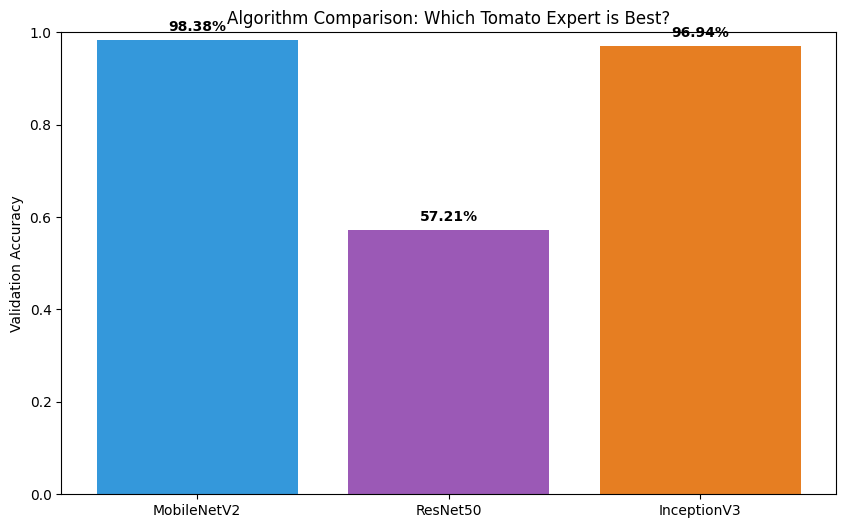


🏆 THE WINNER IS: MobileNetV2 with 98.38% accuracy!


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df_results['Algorithm'], df_results['Best Accuracy'], color=['#3498db', '#9b59b6', '#e67e22'])
plt.ylabel('Validation Accuracy')
plt.title('Algorithm Comparison: Which Tomato Expert is Best?')
plt.ylim(0, 1.0) # Scale from 0 to 100%

# Add text labels on top of bars
for i, val in enumerate(df_results['Best Accuracy']):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center', fontweight='bold')

plt.show()

# Find the winner
winner = df_results.loc[df_results['Best Accuracy'].idxmax()]
print(f"\n🏆 THE WINNER IS: {winner['Algorithm']} with {winner['Best Accuracy']:.2%} accuracy!")

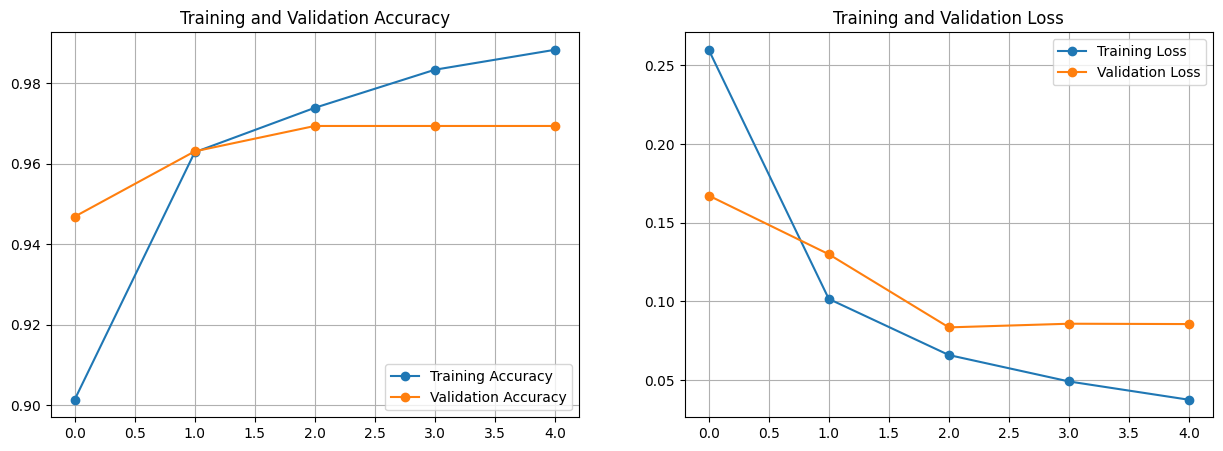

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.show()

plot_learning_curves(history)

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step


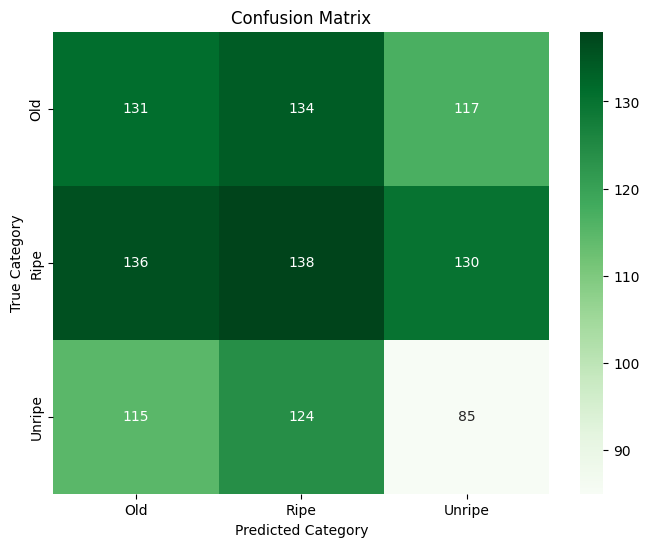

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true labels and predictions from the validation set
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = loaded_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Category')
    plt.xlabel('Predicted Category')
    plt.show()

plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
# Assuming you have a list of results from testing different models
def plot_comparison(results_df):
    plt.figure(figsize=(10, 6))
    colors = ['#ff9999','#66b3ff','#99ff99']
    bars = plt.bar(results_df['Algorithm'], results_df['Best Accuracy'], color=colors)

    plt.ylim(0, 1.1)
    plt.ylabel('Accuracy Score')
    plt.title('Final Algorithm Comparison')

    # Add percentage labels on top
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

    plt.show()

# Example usage:
#plot_comparison(df_results)

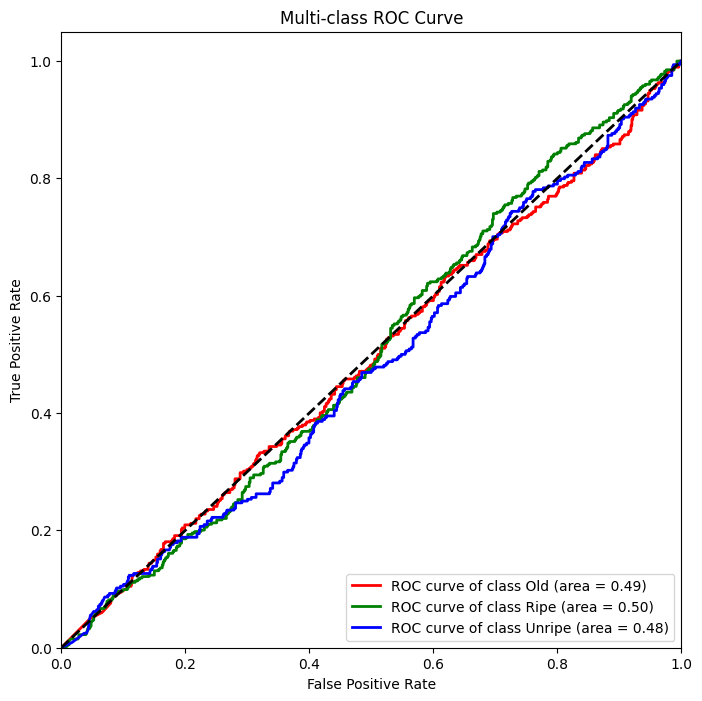

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_roc_curve(y_true, y_pred_probs, classes):
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(8, 8))
    colors = cycle(['red', 'green', 'blue'])

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC curve of class {classes[i]} (area = {roc_auc:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(y_true, y_pred_probs, class_names)